# 02 — Process Performance Map (Camargo BPIC17)

Port of the henryk `02_process_performance_map` notebook, adapted for the Camargo `FullShared_Join_LSTM` baseline.

- **Node label**: activity; color ∝ overall per-source-activity accuracy.
- **Edge label**: `correct / total` predictions for that directly-follows transition.
- **Edge color**: per-transition accuracy (green = high, red = low).

The Camargo model is a single-step next-activity predictor; we iterate prefixes and call it once per prefix to build the performance map.

In [4]:
import sys
from pathlib import Path

# Locate project root and add needed paths
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

project_root = _current
SPEC = utils.BPIC17

model = utils.load_camargo_model(project_root, SPEC)
dataset = utils.load_test_dataset(project_root, SPEC)
window = utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
print(f'Loaded Camargo {SPEC.name} model | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'User_111': 16, 'User_112': 17, 'User_113': 18, 'User_114': 19, 'User_115': 20, 'User_116': 21, 'User_117

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Loaded Camargo BPIC17 model | window=91 | vocab=28 classes | |test|=253196


In [5]:
records = utils.collect_prefix_predictions(predictor, dataset, progress=True)
print(f'Collected {len(records)} prefix predictions')
print(f"Overall accuracy: {sum(r['correct'] for r in records) / len(records) * 100:.1f}%")

Collected 233418 prefix predictions
Overall accuracy: 57.3%


In [6]:
# --- Overall accuracy summary ---
from collections import defaultdict
import pandas as pd

n_total = len(records)
n_correct = sum(1 for r in records if r['correct'])
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    by_plen[r['prefix_length']]['total'] += 1
    by_plen[r['prefix_length']]['correct'] += int(r['correct'])
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

if n_total and 'confidence' in records[0]:
    mean_conf = sum(r['confidence'] for r in records) / n_total
    print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 133846/233418 = 0.5734 (57.34%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1     1556   6301  0.246945
             2     2227   6301  0.353436
             3      671   6301  0.106491
             4     3807   6301  0.604190
             5     1073   6301  0.170290
             6     3845   6301  0.610221
             7     2409   6301  0.382320
             8     3516   6301  0.558007
             9     3101   6301  0.492144
            10     3184   6296  0.505718
            11     2357   6293  0.374543
            12     4228   6290  0.672178
            13     4066   6285  0.646937
            14     3821   6283  0.608149
            15     4077   6277  0.649514
            16     4335   6262  0.692271
            17     4551   6254  0.727694
            18     3738   5991  0.623936
            19     3733   5951  0.627290
            20     4079   5820  0.700859
            21     3434   5575  0.615964
            22

In [7]:
import pandas as pd
from collections import defaultdict

# Per-transition stats (source activity, actual next activity) -> total / correct
stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['actual_next_activity'])
    stats[key]['total'] += 1
    stats[key]['correct'] += int(r['correct'])

# Per-source accuracy (node color)
node_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    node_stats[r['current_activity']]['total'] += 1
    node_stats[r['current_activity']]['correct'] += int(r['correct'])

rows = []
for (src, tgt), s in stats.items():
    rows.append({'source': src, 'target': tgt, 'correct': s['correct'], 'total': s['total'],
                 'accuracy': s['correct'] / s['total']})
transitions_df = pd.DataFrame(rows).sort_values(['source', 'total'], ascending=[True, False])
print(f'{len(transitions_df)} unique transitions')
transitions_df.head(20)

155 unique transitions


,source,target,correct,total,accuracy
8,A_Accepted,O_Create Offer,0,5987,0.000000
63,A_Accepted,W_Complete application,312,312,1.000000
103,A_Accepted,W_Shortened completion,0,1,0.000000
17,A_Cancelled,O_Cancelled,0,2078,0.000000
116,A_Cancelled,W_Call after offers,25,25,1.000000
82,A_Cancelled,W_Call incomplete files,7,7,1.000000
141,A_Cancelled,W_Complete application,2,5,0.400000
15,A_Complete,W_Call after offers,6054,6055,0.999835
66,A_Complete,O_Create Offer,0,116,0.000000
68,A_Complete,O_Cancelled,0,61,0.000000


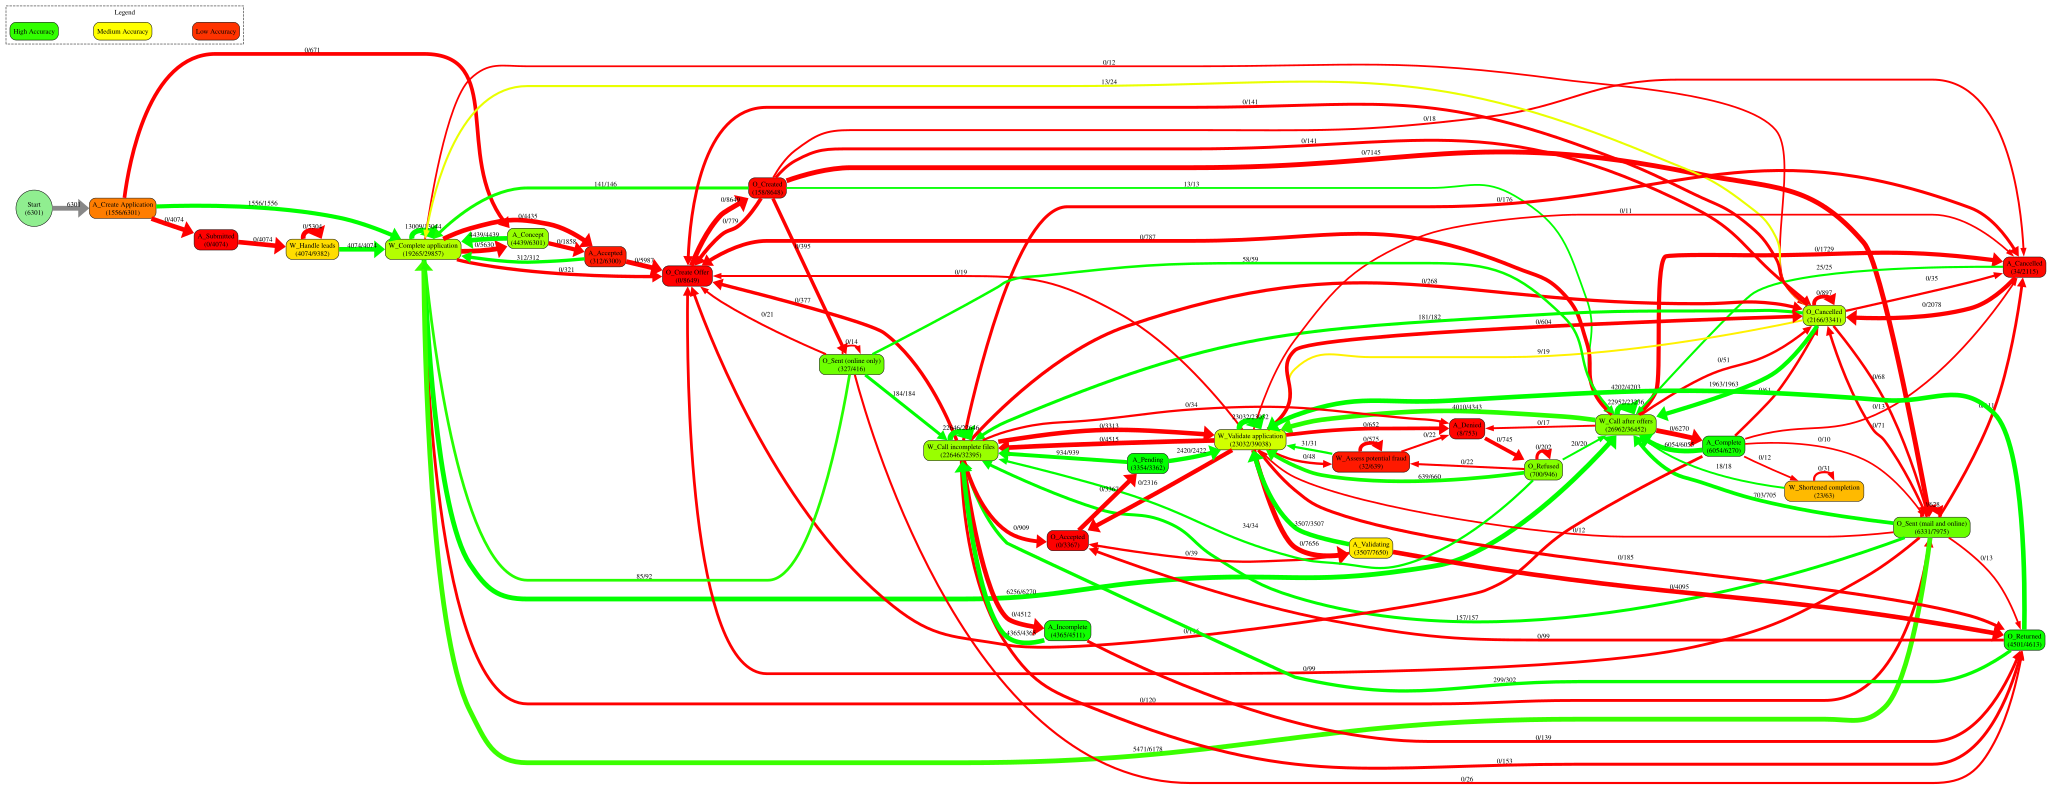

In [8]:
import graphviz
import math

MIN_EDGE_COUNT = 10

def get_color_for_accuracy(accuracy: float) -> str:
    """Red (low) -> Yellow (mid) -> Green (high) gradient -- same as henryk/process_performance_map."""
    if accuracy < 0.5:
        r = 255
        g = int(255 * (accuracy * 2))
        b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2))
        g = 255
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


dot = graphviz.Digraph(comment=f'Camargo {SPEC.name} Process Performance Map')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

for act, s in node_stats.items():
    if s['total'] > 0:
        acc = s['correct'] / s['total']
        label = f"{act}\n({s['correct']}/{s['total']})"
        fill = get_color_for_accuracy(acc)
    else:
        label = str(act)
        fill = 'white'
    dot.node(str(act), label=label, fillcolor=fill)

start_counts = {}
for r in records:
    if r['prefix_length'] == 1:
        start_counts[r['current_activity']] = start_counts.get(r['current_activity'], 0) + 1
total_cases = sum(start_counts.values())
if total_cases:
    dot.node('__START__', label=f'Start\n({total_cases})', shape='circle', fillcolor='#90EE90', style='filled')
    for act, cnt in start_counts.items():
        if cnt >= MIN_EDGE_COUNT:
            dot.edge('__START__', str(act), label=str(cnt), color='#888888',
                     penwidth=str(1 + math.log1p(cnt)))

for (src, tgt), s in stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    label = f"{s['correct']}/{s['total']}"
    dot.edge(str(src), str(tgt), label=label, color=color,
             penwidth=str(1 + math.log1p(s['total'])))

with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

In [9]:
# Per-source summary
print('Per-source-activity accuracy:')
for act, s in sorted(node_stats.items(), key=lambda x: -x[1]['total']):
    acc = s['correct'] / s['total']
    print(f"  {act:<30s} {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per-source-activity accuracy:
  W_Validate application         23032/39038   59.0%
  W_Call after offers            26962/36452   74.0%
  W_Call incomplete files        22646/32395   69.9%
  W_Complete application         19265/29857   64.5%
  W_Handle leads                  4074/9382    43.4%
  O_Create Offer                     0/8649     0.0%
  O_Created                        158/8648     1.8%
  O_Sent (mail and online)        6331/7975    79.4%
  A_Validating                    3507/7650    45.8%
  A_Create Application            1556/6301    24.7%
  A_Concept                       4439/6301    70.4%
  A_Accepted                       312/6300     5.0%
  A_Complete                      6054/6270    96.6%
  O_Returned                      4501/4613    97.6%
  A_Incomplete                    4365/4511    96.8%
  A_Submitted                        0/4074     0.0%
  O_Accepted                         0/3367     0.0%
  A_Pending                       3354/3362    99.8%
  O_Cancelled   